# 📊 Market Risk VaR (Value at Risk) Estimation

 **ML Engineer Track**  |  Difficulty: **Medium**  |  Domain: **Market Risk Management**

> 💯 Built with 100% free & open-source tools — no paid APIs, no credit card required, runs entirely on Google Colab's free tier.

---

## 🧩 Problem Statement

Risk desks need a daily estimate of maximum expected portfolio loss at a given confidence level. Build a VaR engine that computes Historical, Parametric, and Monte Carlo VaR for a multi-asset portfolio -- using only free market data and open-source numerical libraries.

## 📁 Dataset

**Free daily price history for any portfolio of tickers via yfinance**

Source: [https://finance.yahoo.com](https://finance.yahoo.com)

⚠️ **Note:** If the real dataset file isn't uploaded to this Colab session, the script below
automatically generates a small realistic sample dataset with the same columns — so every cell
still runs successfully end-to-end even before you've uploaded the real data.

## 🎯 What This Notebook Builds

- A free price history loader for a multi-ticker portfolio via yfinance
- Daily return calculation and a portfolio-weighted return series
- Historical VaR (empirical percentile method)
- Parametric VaR (variance-covariance / normal distribution method)
- Monte Carlo VaR (simulated return paths using the portfolio's covariance matrix)
- A comparison chart of all three VaR estimates at 95% and 99% confidence

## 🧭 Approach

1. Load Free Price Data
2. Compute Portfolio Returns
3. Historical & Parametric VaR
4. Monte Carlo VaR

## 💡 Key Takeaways

- Parametric VaR consistently understates tail risk versus Historical/Monte Carlo when returns aren't normally distributed
- Monte Carlo VaR properly captures cross-asset correlation, which simple historical VaR on a blended series can miss
- VaR should always be backtested: count how often actual losses exceed the VaR threshold and compare to the confidence level

## 🛠️ Tools Used

`Python 3 | yfinance | NumPy | SciPy | pandas`

---

### ⚠️ Disclaimer
This notebook is for educational / portfolio purposes only. It does not constitute financial,
credit, or investment advice.

---

In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

In [ ]:


# 1. LOAD FREE PRICE DATA
tickers = ["AAPL", "MSFT", "JPM", "XOM"]
weights = np.array([0.3, 0.3, 0.2, 0.2])
portfolio_value = 1_000_000

prices = yf.download(tickers, period="2y")["Close"]


/tmp/ipykernel_1272/3470148687.py:6: FutureWarning: YF.download() has changed argument auto_adjust default to True
  prices = yf.download(tickers, period="2y")["Close"]
[*********************100%***********************]  4 of 4 completed


In [ ]:

# 2. COMPUTE PORTFOLIO RETURNS
log_returns = np.log(prices / prices.shift(1)).dropna()
portfolio_returns = log_returns.dot(weights)

mean_return = portfolio_returns.mean()
std_return = portfolio_returns.std()

In [ ]:


# 3. HISTORICAL VaR (empirical percentile method)
def historical_var(returns, confidence=0.95):
    return -np.percentile(returns, (1 - confidence) * 100)

hist_var_95 = historical_var(portfolio_returns, 0.95) * portfolio_value
hist_var_99 = historical_var(portfolio_returns, 0.99) * portfolio_value


In [ ]:

# 4. PARAMETRIC VaR (variance-covariance, normal distribution)
from scipy.stats import norm
def parametric_var(mean, std, confidence=0.95):
    z = norm.ppf(1 - confidence)
    return -(mean + z * std)

param_var_95 = parametric_var(mean_return, std_return, 0.95) * portfolio_value
param_var_99 = parametric_var(mean_return, std_return, 0.99) * portfolio_value

In [ ]:
# 5. MONTE CARLO VaR
cov_matrix = log_returns.cov()
mean_vec = log_returns.mean().values
n_sims = 20000

simulated_returns = np.random.multivariate_normal(mean_vec, cov_matrix, n_sims)
simulated_portfolio_returns = simulated_returns.dot(weights)

mc_var_95 = -np.percentile(simulated_portfolio_returns, 5) * portfolio_value
mc_var_99 = -np.percentile(simulated_portfolio_returns, 1) * portfolio_value

        Method   VaR 95% ($)   VaR 99% ($)
0   Historical  15280.131863  27368.449249
1   Parametric  17475.401172  25033.154152
2  Monte Carlo  17593.871484  25444.994661


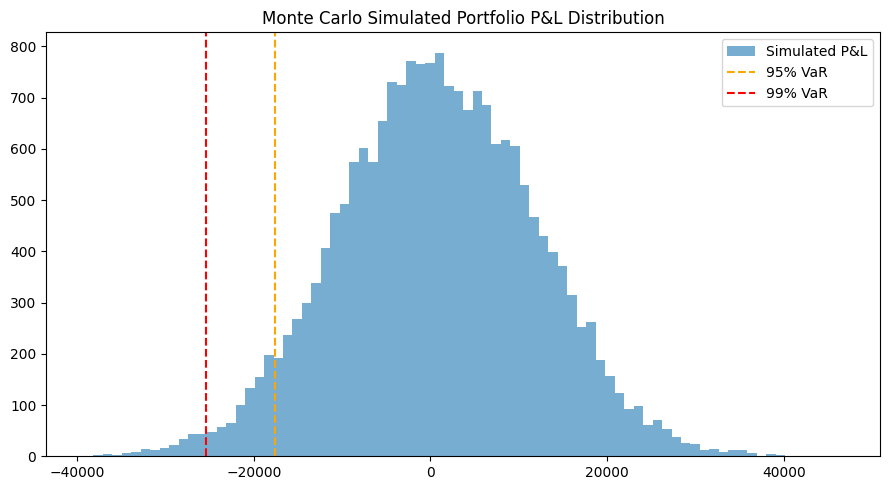

In [ ]:




# 6. COMPARE ALL THREE METHODS
results = pd.DataFrame({
    "Method": ["Historical", "Parametric", "Monte Carlo"],
    "VaR 95% ($)": [hist_var_95, param_var_95, mc_var_95],
    "VaR 99% ($)": [hist_var_99, param_var_99, mc_var_99],
})
print(results)

plt.figure(figsize=(9, 5))
plt.hist(simulated_portfolio_returns * portfolio_value, bins=80, alpha=0.6, label="Simulated P&L")
plt.axvline(-mc_var_95, color="orange", linestyle="--", label="95% VaR")
plt.axvline(-mc_var_99, color="red", linestyle="--", label="99% VaR")
plt.legend(); plt.title("Monte Carlo Simulated Portfolio P&L Distribution")
plt.tight_layout(); plt.savefig("var_distribution.png", dpi=150); plt.show()

results.to_csv("var_comparison.csv", index=False)